In [2]:
import os
import subprocess
import numpy as np
import pandas as pd

my_bucket = os.getenv('WORKSPACE_BUCKET')


# Load in Data

## Individual-level SES

In [20]:
os.system(f"gsutil cp '{my_bucket}/data/all_WGS_demographics.csv' .")

# Read CSV and select only desired columns
ses = pd.read_csv(
    'all_WGS_demographics.csv',
    usecols=["person_id", "income", "number_living", "education", "basics_survey_datetime"]
)


# Clean and format datetime

# Ensure is in datetime format
ses['basics_survey_datetime'] = pd.to_datetime(ses['basics_survey_datetime'], errors='coerce')

# Remove timezone info if present
ses['basics_survey_datetime'] = ses['basics_survey_datetime'].dt.tz_localize(None)

# extract year-month as timestamp
# was in format 2019-05-18 00:16:27 but just need 2019-05-18
ses['survey_datetime'] = ses['basics_survey_datetime'].dt.to_period('M').dt.to_timestamp()

# Drop the original column
ses = ses.drop(columns=['basics_survey_datetime'])

#Drop those without education data
ses = ses[ses['education'] != 'Skip or PNA']

#Comvert Education to semi-continous numeric
# Define mapping for the semi-continuous 5-level education variable
education_mapping = {
    "Less than high school degree or equivalent": 5,
    "Twelve or GED": 4,
    "College One to Three": 3,
    "College graduate": 2,
    "Advanced degree": 1
}

# Apply mapping to create a new numeric column
ses["education"] = ses["education"].map(education_mapping)


# -----------------------------
# Final Format Notes:
# -----------------------------
# Columns: 
# - person_id (int)
# - number_living (int)
# - education (int) 1 (advanced degree) to 5 (less than highschool)
# - income (numeric: 5000, 12500, 30000, 42500, 62500, 87500, 125000, 175000, 225000 or NaN)
# - survey_datetime (datetime object, year-day-month, e.g., 2019-05-18)

ses.info()

Copying gs://fc-secure-61ffe592-139f-4be1-8b47-8dbe2adbb1eb/data/all_WGS_demographics.csv...
\ [1 files][159.5 MiB/159.5 MiB]                                                
Operation completed over 1 objects/159.5 MiB.                                    


<class 'pandas.core.frame.DataFrame'>
Index: 282828 entries, 0 to 289190
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   person_id        282828 non-null  int64         
 1   number_living    275707 non-null  float64       
 2   education        282828 non-null  int64         
 3   income           227969 non-null  float64       
 4   survey_datetime  282828 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 12.9 MB


## Zip Code

In [21]:
# This query represents dataset "zip_code_socio" for domain "zip_code_socioeconomic" and was generated for All of Us Controlled Tier Dataset v8
dataset_27222903_zip_code_socioeconomic_sql = """
    SELECT
        observation.person_id,
        observation.observation_datetime,
        zip_code.zip3_as_string as zip_code
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.zip3_ses_map` zip_code 
    JOIN
        `""" + os.environ["WORKSPACE_CDR"] + """.observation` observation 
            ON CAST(SUBSTR(observation.value_as_string, 0, STRPOS(observation.value_as_string, '*') - 1) AS INT64) = zip_code.zip3 
            AND observation_source_concept_id = 1585250 
            AND observation.value_as_string NOT LIKE 'Res%'"""

zip_code_socioeconomic_df = pd.read_gbq(
    dataset_27222903_zip_code_socioeconomic_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

# -----------------------------
# Final Format Notes:
# -----------------------------
# Columns: 
# - person_id (int)
# - observation_datetime (datetime object, e.g., 2019-05-18 00:16:27)
# - zip_code (object, e.g. 353**)

zip_code_socioeconomic_df.info()

Downloading:   0%|          | 0/606414 [00:00<?, ?rows/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606414 entries, 0 to 606413
Data columns (total 3 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   person_id             606414 non-null  Int64              
 1   observation_datetime  606414 non-null  datetime64[ns, UTC]
 2   zip_code              606414 non-null  object             
dtypes: Int64(1), datetime64[ns, UTC](1), object(1)
memory usage: 14.5+ MB


## National Poverty Guidelines

In [22]:
#Provided in Github micah-r-hysong/PRS_SDoH_analysis/poverty_guidelines

files = {
    "poverty-guidelines-48-states.csv": "pov_states",
    "poverty-guidelines-hawaii.csv": "pov_hawaii",
    "poverty-guidelines-alaska.csv": "pov_alaska"
}

# Loop over files, copy from bucket, and read into pandas
for file_name, var_name in files.items():
    source_path = f"{my_bucket}/data/{file_name}"
    os.system(f"gsutil cp '{source_path}' .")
    globals()[var_name] = pd.read_csv(file_name)

Copying gs://fc-secure-61ffe592-139f-4be1-8b47-8dbe2adbb1eb/data/poverty-guidelines-48-states.csv...
/ [1 files][ 12.1 KiB/ 12.1 KiB]                                                
Operation completed over 1 objects/12.1 KiB.                                     
Copying gs://fc-secure-61ffe592-139f-4be1-8b47-8dbe2adbb1eb/data/poverty-guidelines-hawaii.csv...
/ [1 files][ 11.4 KiB/ 11.4 KiB]                                                
Operation completed over 1 objects/11.4 KiB.                                     
Copying gs://fc-secure-61ffe592-139f-4be1-8b47-8dbe2adbb1eb/data/poverty-guidelines-alaska.csv...
/ [1 files][ 11.4 KiB/ 11.4 KiB]                                                
Operation completed over 1 objects/11.4 KiB.                                     


## ACS Data

In [23]:
#Provided in Github micah-r-hysong/ACS_metrics/ACS_data_2013_2023.csv

os.system(f"gsutil cp '{my_bucket}/data/ACS_data_2013_2023.csv' .")

# Read CSV 
acs_data = pd.read_csv(
    'ACS_data_2013_2023.csv')



Copying gs://fc-secure-61ffe592-139f-4be1-8b47-8dbe2adbb1eb/data/ACS_data_2013_2023.csv...
/ [1 files][  1.3 MiB/  1.3 MiB]                                                
Operation completed over 1 objects/1.3 MiB.                                      


# Make Percent of Poverty Threshold Score

In [24]:
# --- Clean and format date columns (handles mixed formats safely) ---
for df in [pov_states, pov_hawaii, pov_alaska]:
    df['Date of Publication'] = pd.to_datetime(
        df['Date of Publication'],
        format='mixed',   # allows mixed date styles, e.g. 'Jan-72' and 'January 2020'
        errors='coerce'   # convert invalid formats to NaT
    )
    df['Date of Publication'] = df['Date of Publication'].dt.tz_localize(None)


In [25]:
# Function to assign location based on zip_code
def assign_location(zip_code):
    if zip_code.startswith('995'):
        return 'alaska'
    elif zip_code.startswith('967'):
        return 'hawaii'
    else:
        return 'states'

# Apply the function to create the location column
zip_code_socioeconomic_df['location'] = zip_code_socioeconomic_df['zip_code'].apply(assign_location)

# Create new DataFrame with person_id and location columns
demo_df = zip_code_socioeconomic_df[['person_id', 'location']]

#Add in ses
demo_df = pd.merge(demo_df, ses, on="person_id")

print(demo_df['location'].value_counts())

demo_df.info()

location
states    271658
hawaii        52
alaska        10
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271720 entries, 0 to 271719
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   person_id        271720 non-null  Int64         
 1   location         271720 non-null  object        
 2   number_living    265014 non-null  float64       
 3   education        271720 non-null  int64         
 4   income           219215 non-null  float64       
 5   survey_datetime  271720 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 12.7+ MB


In [26]:
# Function to find the closest date in pov_df and calculate the distance in months
def find_closest_date_and_distance(demo_date, pov_df):
    pov_df['date_diff'] = (pov_df['Date of Publication'] - demo_date).abs()
    closest_row = pov_df.loc[pov_df['date_diff'].idxmin()]
    distance_in_months = (closest_row['Date of Publication'].year - demo_date.year) * 12 + (closest_row['Date of Publication'].month - demo_date.month)
    distance_in_months = abs(distance_in_months)
    return closest_row, distance_in_months

# Function to merge demo_df with the closest date in pov_df and calculate the poverty threshold
def merge_and_calculate_threshold(demo, pov):
    merged_rows = []
    for _, demo_row in demo.iterrows():
        closest_pov_row, distance_in_months = find_closest_date_and_distance(demo_row['survey_datetime'], pov)
        merged_row = pd.concat([demo_row, closest_pov_row])
        merged_row['distance_in_months'] = distance_in_months
        merged_rows.append(merged_row)
    merged_df = pd.DataFrame(merged_rows)
    
    # Calculate poverty threshold
    def get_poverty_threshold(row):
        if row['number_living'] == 1:
            return row['1 Person']
        elif row['number_living'] == 2:
            return row['2 Persons']
        elif row['number_living'] == 3:
            return row['3 Persons']
        elif row['number_living'] == 4:
            return row['4 Persons']
        elif row['number_living'] == 5:
            return row['5 Persons']
        elif row['number_living'] == 6:
            return row['6 Persons']
        elif row['number_living'] == 7:
            return row['7 Persons']
        elif row['number_living'] == 8:
            return row['8 Persons']
        else:
            return row['8 Persons'] + (row['number_living'] - 8) * row['$ For Each Additional Person (9+)']
    
    merged_df['poverty_threshold'] = merged_df.apply(get_poverty_threshold, axis=1)
    return merged_df

# Separate demo_df into states and hawaii DataFrames
demo_states = demo_df[demo_df['location'] == 'states']
demo_hawaii = demo_df[demo_df['location'] == 'hawaii']
demo_alaska = demo_df[demo_df['location'] == 'alaska']

# Merge with the respective poverty data
print(demo_states.shape[0])
merged_states = merge_and_calculate_threshold(demo_states, pov_states)
print(merged_states.shape[0])

print(demo_hawaii.shape[0])
merged_hawaii = merge_and_calculate_threshold(demo_hawaii, pov_hawaii)
print(merged_hawaii.shape[0])

print(demo_alaska.shape[0])
merged_alaska = merge_and_calculate_threshold(demo_alaska, pov_alaska)
print(merged_alaska.shape[0])

# Combine the two DataFrames
final_df = pd.concat([merged_states, merged_hawaii, merged_alaska])

# Select the relevant columns to form the final DataFrame
final_df = final_df[['person_id', 'income', 'number_living', 'education', 'survey_datetime', 'poverty_threshold', 'distance_in_months']]

final_df.info()

271658
271658
52
52
10
10
<class 'pandas.core.frame.DataFrame'>
Index: 271720 entries, Unnamed 0 to 9
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   person_id           271720 non-null  int64         
 1   income              219215 non-null  float64       
 2   number_living       265014 non-null  float64       
 3   education           271720 non-null  int64         
 4   survey_datetime     271720 non-null  datetime64[ns]
 5   poverty_threshold   265014 non-null  float64       
 6   distance_in_months  271720 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 16.6+ MB


<Axes: >

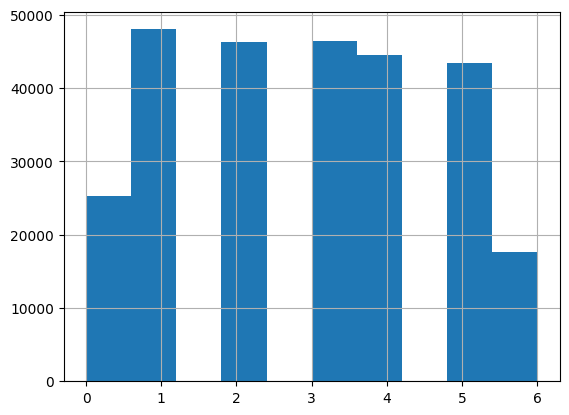

In [27]:
#Make sure our survey datetime and poverty guidelines are close enough in time
final_df['distance_in_months'].hist()

<Axes: >

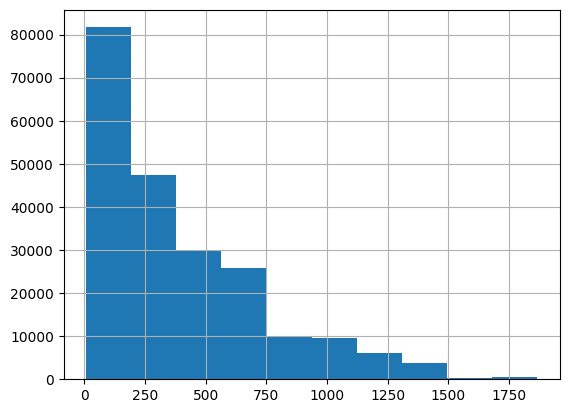

In [28]:
#Make actual percent of poverty score

final_df['per_poverty_threshold']=final_df['income']/final_df['poverty_threshold']*100
final_df['per_poverty_threshold'].hist()

In [29]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 271720 entries, Unnamed 0 to 9
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   person_id              271720 non-null  int64         
 1   income                 219215 non-null  float64       
 2   number_living          265014 non-null  float64       
 3   education              271720 non-null  int64         
 4   survey_datetime        271720 non-null  datetime64[ns]
 5   poverty_threshold      265014 non-null  float64       
 6   distance_in_months     271720 non-null  int64         
 7   per_poverty_threshold  215029 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 18.7+ MB


# Get area-level Data

In [30]:
# Ensure zip codes are strings
zip_code_socioeconomic_df['zip_code'] = zip_code_socioeconomic_df['zip_code'].astype(str)
zip_code_socioeconomic_df['zip_prefix'] = zip_code_socioeconomic_df['zip_code'].str[:3].str.zfill(3)

# Extract the first three digits from both for matching
acs_data['zip_prefix'] = acs_data['zip3'].astype(str)
acs_data['zip_prefix'] = acs_data['zip_prefix'].str[:3].str.zfill(3)

# --- Extract observation year ---
zip_code_socioeconomic_df['obs_year'] = zip_code_socioeconomic_df['observation_datetime'].dt.year

print("Start:", zip_code_socioeconomic_df['person_id'].nunique())

# --- Merge on zip prefix to get all potential matches ---
merged = pd.merge(
    zip_code_socioeconomic_df,
    acs_data,
    on='zip_prefix',
    how='left',
    suffixes=('_socio', '_acs')
)

print("After merge:", merged['person_id'].nunique())


# --- Compute year difference and select closest ACS year for each person_id ---
merged['year_diff'] = abs(merged['obs_year'] - merged['year'])

# --- Drop rows where year_diff is NaN (no valid ACS year match) ---
merged = merged.dropna(subset=['year_diff'])

print("After dropna:", merged.dropna(subset=['year_diff'])['person_id'].nunique())


# --- Select closest ACS year for each person_id ---
idx = merged.groupby('person_id')['year_diff'].idxmin()
merged_closest = (
    merged.loc[idx]
    .reset_index(drop=True)
)


Start: 606414
After merge: 606414
After dropna: 603264


<Axes: >

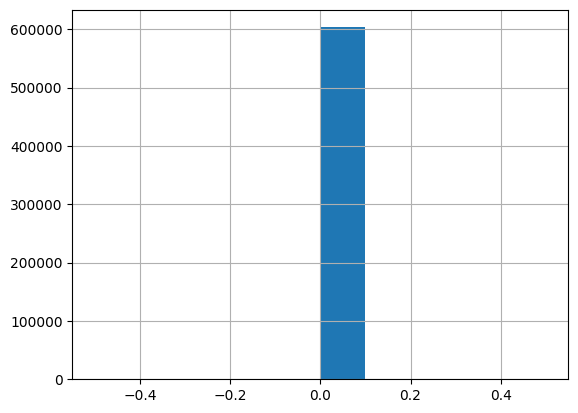

In [31]:
#Make sure our survey datetime and acs info are close enough in time
merged_closest['year_diff'].hist()

In [32]:
merged_closest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603264 entries, 0 to 603263
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   person_id                     603264 non-null  Int64              
 1   observation_datetime          603264 non-null  datetime64[ns, UTC]
 2   zip_code                      603264 non-null  object             
 3   location                      603264 non-null  object             
 4   zip_prefix                    603264 non-null  object             
 5   obs_year                      603264 non-null  int32              
 6   zip3                          603264 non-null  float64            
 7   year                          603264 non-null  float64            
 8   fraction_assisted_income      603244 non-null  float64            
 9   fraction_high_school_edu      603247 non-null  float64            
 10  median_income       

# Make Final SES dataframe

In [33]:
# Drop unnecessary columns
merged_closest = merged_closest.drop(
    columns=['observation_datetime', 'zip_code', 'location', 'zip_prefix', 'obs_year', 'zip3', 'year', 'year_diff'],
    errors='ignore'  # prevents error if a column is missing
)

final_df = final_df.drop(
    columns = ['distance_in_months', 'number_living', 'survey_datetime', 'poverty_threshold'],
    errors='ignore'  # prevents error if a column is missing
)

# Merge with final_df on person_id
final_merged = pd.merge(
    final_df,
    merged_closest,
    on='person_id',
    how='inner'
)

final_merged = final_merged.dropna()


final_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214915 entries, 0 to 271600
Data columns (total 11 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   person_id                     214915 non-null  int64  
 1   income                        214915 non-null  float64
 2   education                     214915 non-null  int64  
 3   per_poverty_threshold         214915 non-null  float64
 4   fraction_assisted_income      214915 non-null  float64
 5   fraction_high_school_edu      214915 non-null  float64
 6   median_income                 214915 non-null  float64
 7   fraction_no_health_insurance  214915 non-null  float64
 8   fraction_poverty              214915 non-null  float64
 9   fraction_vacant_housing       214915 non-null  float64
 10  deprivation_index             214915 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 19.7 MB


In [34]:
#Save file
final_merged.to_csv('SES_data.csv', index=False)
args = ["gsutil", "cp", f"./SES_data.csv", f"{my_bucket}/data/"]
output = subprocess.run(args, capture_output=True)